<a href="https://colab.research.google.com/github/TheDataBadger/DSPP/blob/main/Childcare_Affordability_and_National_Happiness_(K_Means).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Apprenticeship Data Science project

Data Science Professional Practice Module

Aug 2026

# **Identifying Country Groupings using Childcare Affordability and National Happiness (K-Means)**

# Introduction

This project clusters countries in the OECD via K-means, using data Childcare costs as a % of disposable household income, and World happiness data.
These clusters provide insight into childcare affordability and how other socio-economic factors may impact wellbeing.

This notebook uses a merged dataset containing:

* World Happiness Index Score (WHR)
* % Net Childcare Costs (OECD)
* GDP Per Capita (WHR)
* Social Support (WHR)
* Healthy life expectancy (WHR)
* % Population < 14 (World Bank)


Data Source links:

[World Happiness Report Data (2023) (WHR)](https://files.worldhappiness.report/WHR23_Data_Figure_2.1.xls)

[OECD – PF3.4 Net Childcare Costs (2023) (OECD)](https://www.oecd.org/els/family/PF3_4_Childcare_costs.pdf)

[World Bank – Population Ages 0–14 (% of total) (2023)](https://data.worldbank.org/indicator/SP.POP.0014.TO.ZS)


In [ ]:
#====================
# Step 1. Setup & Imports
#====================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


sns.set_context("notebook")
plt.rcParams.update({"font.size": 10})


In [ ]:
#====================
# 2. Mount Datasets Google Drive
#====================

# For ease and clarity a merge file of the relevant datasets and columns has been created in Power Query, and loaded into Google Drive.
# Only countries with childcare costs have been included as this is a core measure
# Country names have been standardised and ISO3 Codes added for choropleth ability

# Load the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#====================
# 3. Load Data
#====================

datafile = "/content/drive/MyDrive/Datasets/Merged Childcare WHR Data.csv"

df = pd.read_csv(datafile)

print(df.head())
print(df.columns)

     Country Name  ISO          Region  World Happiness Index Score (WHR) *  \
0     New Zealand  NZL         Oceania                               7.1229   
1   United States  USA   North America                               6.8937   
2         Ireland  IRL  Western Europe                               6.9108   
3  United Kingdom  GBR  Western Europe                               6.7956   
4       Australia  AUS         Oceania                               7.0946   

   % Net Childcare Costs ((OECD)  *  GDP Per Capita (WHR)  \
0                                23             10.661865   
1                                25             11.048249   
2                                15             11.527362   
3                                16             10.704245   
4                                12             10.821049   

   Social Support (WHR)  Healthy life expectancy (WHR)  \
0              0.952398                      70.350052   
1              0.919162                   

In [ ]:
# =========================
# 4. Data Cleaning
# =========================

# Rename columns to simpler names for coding clarity
df = df.rename(columns={
    "World Happiness Index Score (WHR) *": "happiness",
    "% Net Childcare Costs ((OECD)  *": "net_childcare_cost",
    "GDP Per Capita (WHR)": "gdp",
    "Healthy life expectancy (WHR)": "life_exp",
    "% Population < 14 (World Bank) ": "pop_0_14"
})

print(df.columns)

# Define Features potentially relevant for K means
features = ["happiness",
            "net_childcare_cost",
            "gdp",
            "life_exp",
            "pop_0_14"]
X = df[features]


# Apply Standard Scaler (Z Score) to ensure all features contribute equally and  reduce skew
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = df.copy()
df_scaled[features] = X_scaled

print(df_scaled.head())

Index(['Country Name', 'ISO', 'Region', 'happiness', 'net_childcare_cost',
       'gdp', 'Social Support (WHR)', 'life_exp', 'pop_0_14', 'Year'],
      dtype='object')
     Country Name  ISO          Region  happiness  net_childcare_cost  \
0     New Zealand  NZL         Oceania   0.732839            2.426713   
1   United States  USA   North America   0.315184            2.749708   
2         Ireland  IRL  Western Europe   0.346344            1.134733   
3  United Kingdom  GBR  Western Europe   0.136423            1.296230   
4       Australia  AUS         Oceania   0.681270            0.650240   

        gdp  Social Support (WHR)  life_exp  pop_0_14  Year  
0 -0.156524              0.952398 -0.130546  1.023634  2023  
1  1.070146              0.919162 -2.327958  0.732090  2023  
2  2.591206              0.905368  0.333326  1.263679  2023  
3 -0.021981              0.882205 -0.154987  0.662765  2023  
4  0.348843              0.933870  0.211235  0.894902  2023  


In [ ]:
# =========================
# 5. EDA – Summary Statistics
# =========================

df[features].describe().T


,count,mean,std,min,25%,50%,75%,max
happiness,38.0,6.720734,0.556144,5.466100,6.269750,6.779300,7.116500,7.804200
net_childcare_cost,38.0,7.973684,6.275163,0.000000,4.000000,6.000000,10.750000,25.000000
gdp,38.0,10.711168,0.319214,10.086685,10.540560,10.661366,10.881770,11.659949
life_exp,38.0,70.617381,2.075262,65.850250,69.199850,71.200096,71.956253,74.349464
pop_0_14,38.0,15.635748,2.711667,10.970817,14.348341,15.489090,16.452761,27.614615


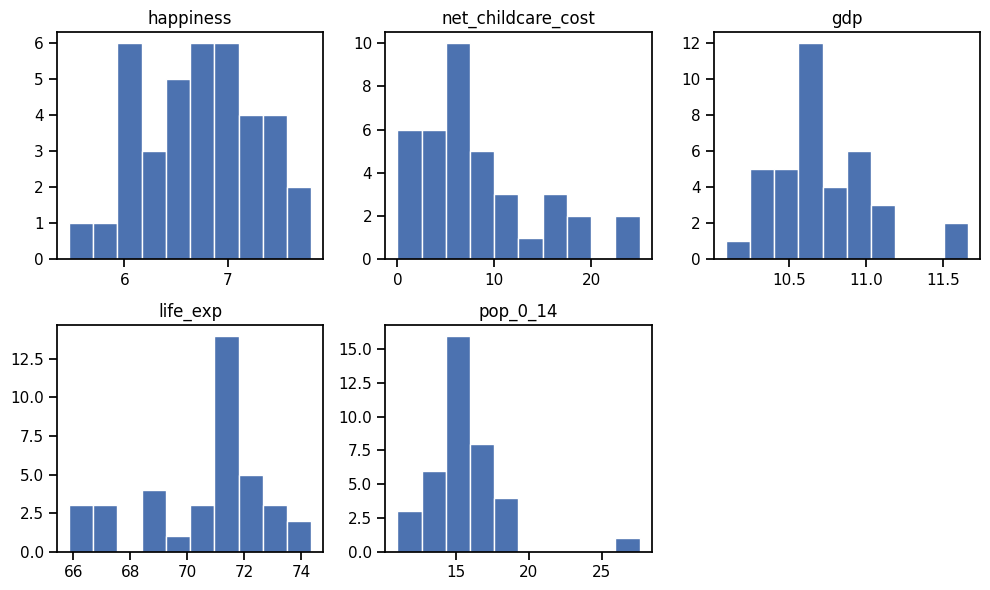

In [ ]:
# =========================
# 6. EDA – Histograms
# =========================

fig, axes = plt.subplots(2, 3, figsize=(10,6))

for ax, col in zip(axes.flatten(), features):
    ax.hist(df[col], bins=10, color="#4C72B0", edgecolor="white")
    ax.set_title(col)

# Remove the unused last axis
for ax in axes.flatten()[len(features):]:
    ax.remove()

plt.tight_layout()
plt.show()


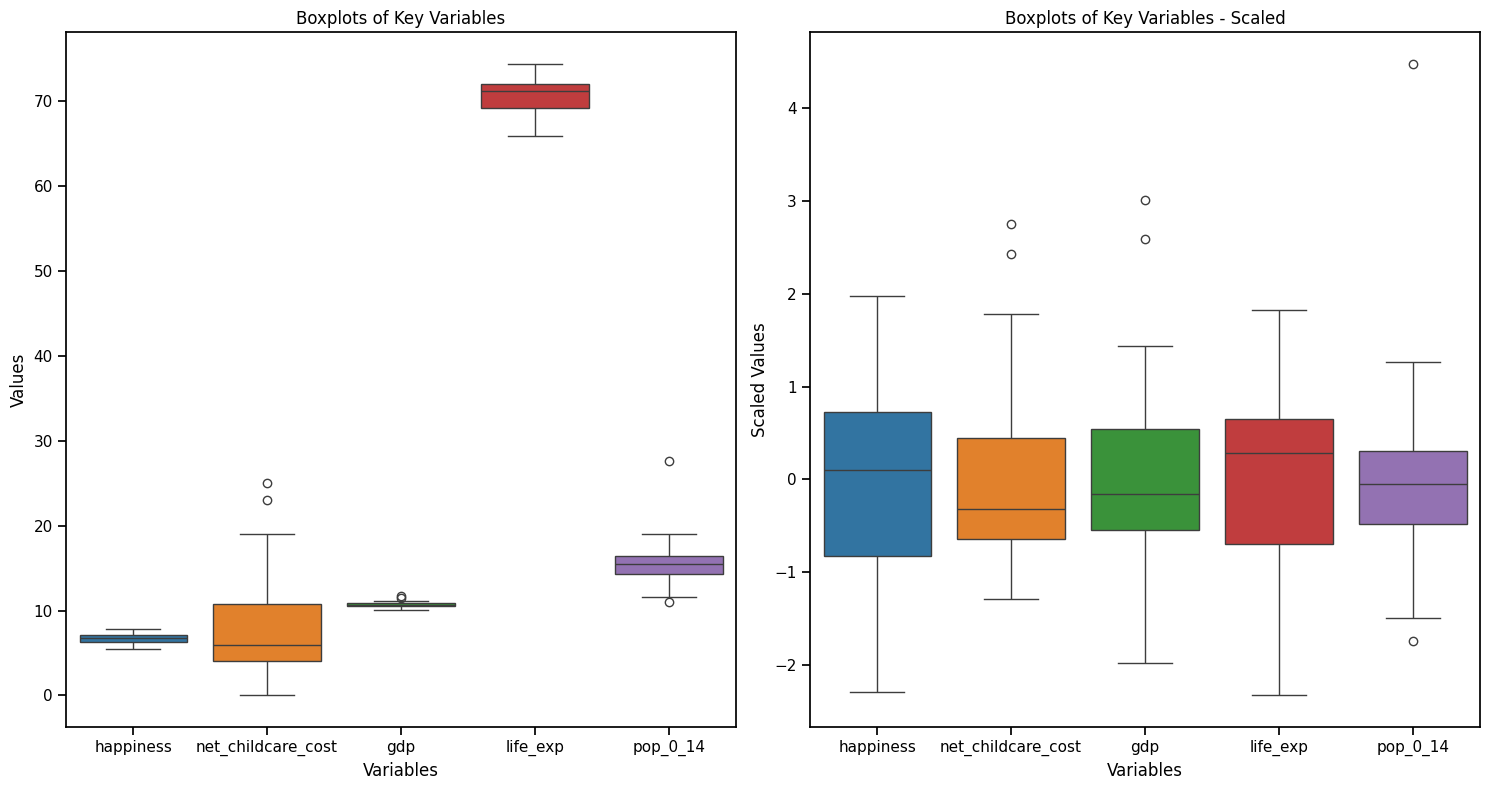

In [ ]:

# =========================
# 7. EDA – Boxplots
# =========================

fig, axes = plt.subplots(1, 2, figsize=(15,8))
# --- Original values ---
sns.boxplot(
    data=df[["happiness", "net_childcare_cost", "gdp", "life_exp", "pop_0_14"]],
    ax=axes[0]
)
axes[0].set_title("Boxplots of Key Variables")
axes[0].set_xlabel("Variables")
axes[0].set_ylabel("Values")

# --- Scaled values ---
sns.boxplot(
    data=df_scaled[["happiness", "net_childcare_cost", "gdp", "life_exp", "pop_0_14"]],
    ax=axes[1]
)
axes[1].set_title("Boxplots of Key Variables - Scaled")
axes[1].set_xlabel("Variables")
axes[1].set_ylabel("Scaled Values")

plt.tight_layout()
plt.show()


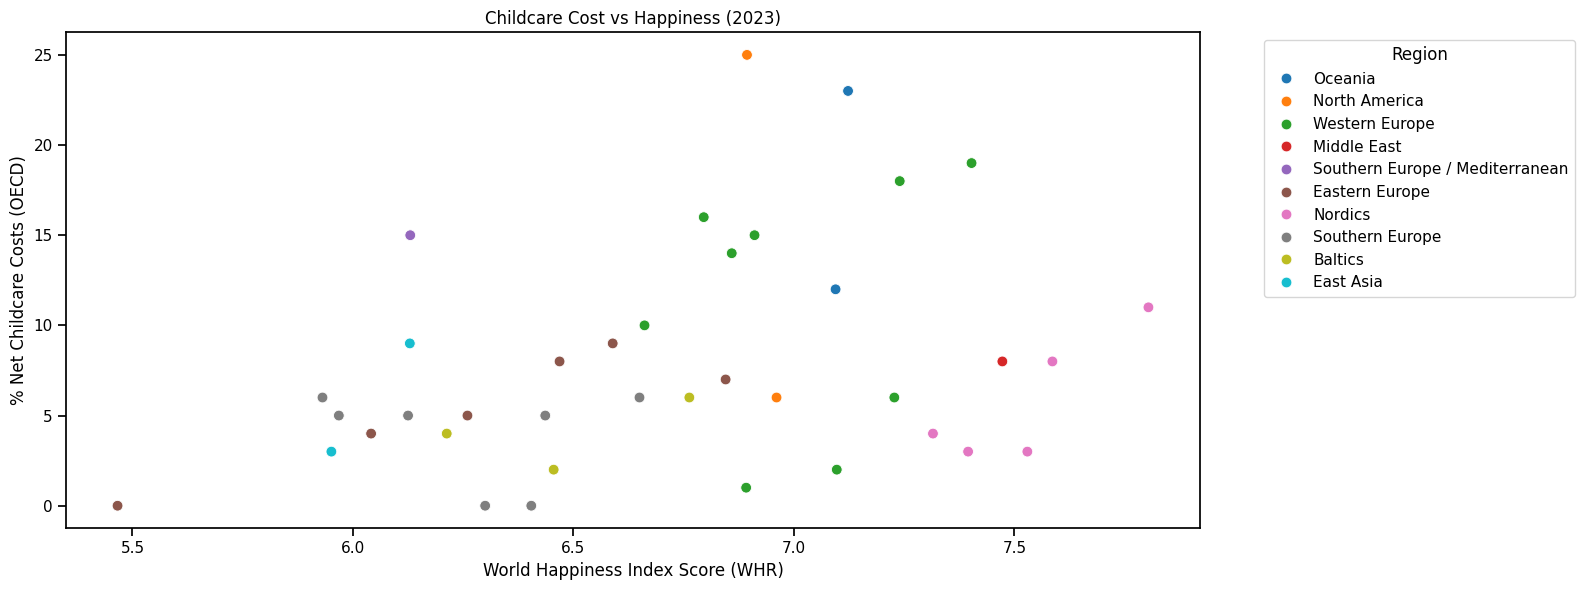

In [ ]:
# =========================
# 8. EDA – Scatter Plot: Childcare Cost vs Happiness
# =========================

plt.figure(figsize=(16,6))
sns.scatterplot(
    data=df,
    x="happiness",
    y="net_childcare_cost",
    hue="Region",
    palette="tab10",
    s= 60
)
plt.title("Childcare Cost vs Happiness (2023)")
plt.ylabel("% Net Childcare Costs (OECD)")
plt.xlabel("World Happiness Index Score (WHR)")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


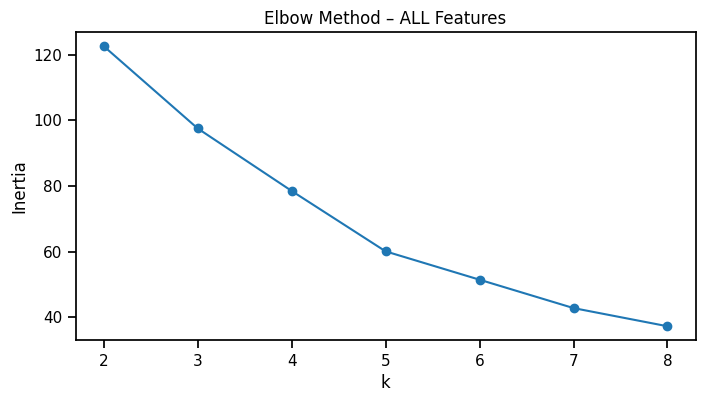

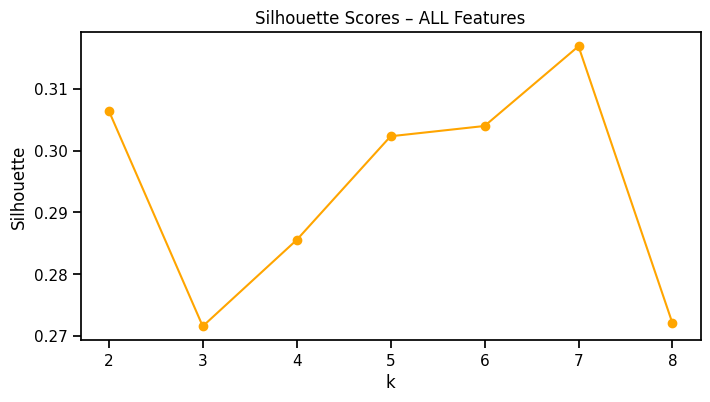

ALL inertias: [(2, 122.55195837860786), (3, 97.5119971618175), (4, 78.48011822161575), (5, 60.0805142853881), (6, 51.44860853630237), (7, 42.80712007279311), (8, 37.275194143291124)]
ALL silhouettes: [(2, np.float64(0.30641803528783845)), (3, np.float64(0.27163809185004356)), (4, np.float64(0.2855666050753632)), (5, np.float64(0.30230229918767454)), (6, np.float64(0.30395962177932867)), (7, np.float64(0.31682804129464304)), (8, np.float64(0.272128470802249))]


In [ ]:
# =========================
# 9. EDA – Elbow + Silhouette (ALL)
# =========================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K = range(2, 9)

# ---------------------------------------------------
# A. Elbow + Silhouette on ALL features
# ---------------------------------------------------

inertias_all = []
silhouettes_all = []

for k in K:
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias_all.append(km.inertia_)
    silhouettes_all.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,4))
plt.plot(K, inertias_all, marker='o')
plt.title("Elbow Method – ALL Features")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(K, silhouettes_all, marker='o', color="orange")
plt.title("Silhouette Scores – ALL Features")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

print("ALL inertias:", list(zip(K, inertias_all)))
print("ALL silhouettes:", list(zip(K, silhouettes_all)))


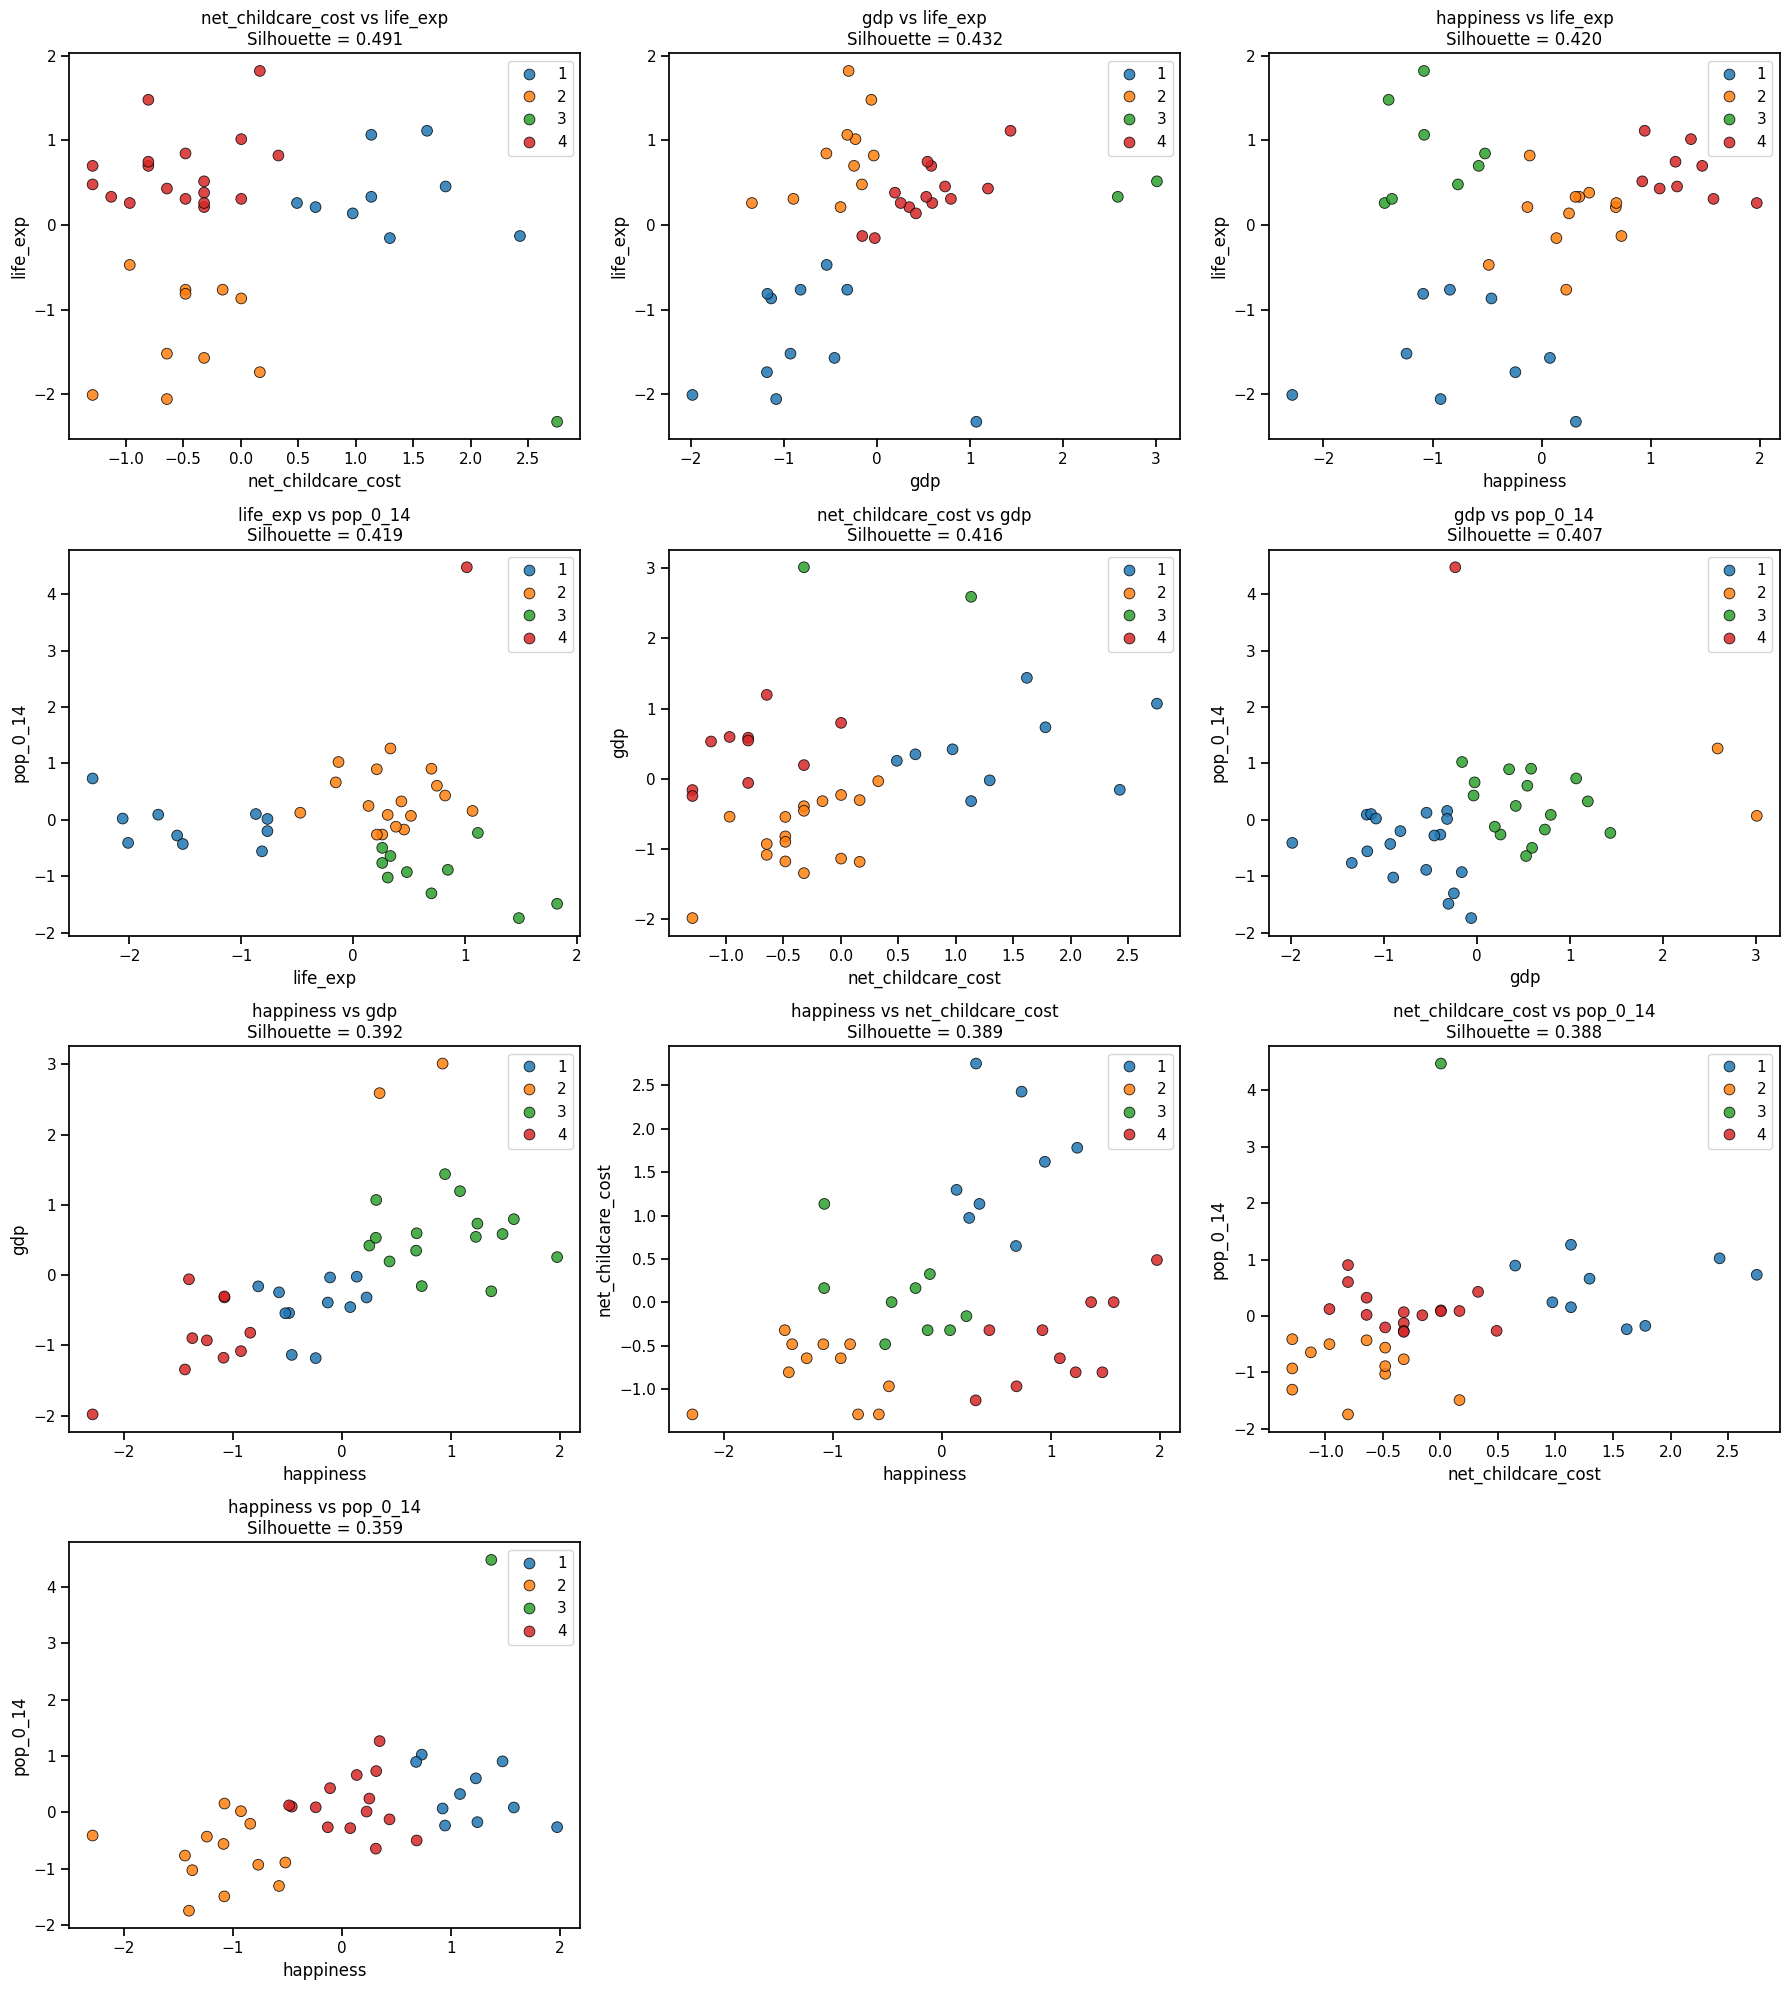

In [ ]:
import itertools

# =========================
# 9. EDA - Exploring possible relevant variable combinations for further exploration
# =========================

#This step explores which pairs of variables naturally form clusters.
#High silhouette scores help identify which features may drive meaningful groupings

best_k = 4

#used for exploratory only, value kept the same to keep consistency, and avoids bias.
#K 4 was chosen as this is the Elbow point on all the data in step 8. This is not the final cluster coun.

pair_scores_with_labels = []

for x, y in itertools.combinations(features, 2):
    X_pair = df_scaled[[x, y]].values

    # Use best_k as n_clusters, since df_scaled does not have 'cluster' column
    km = KMeans(n_clusters=best_k, n_init=50, random_state=42)
    labels = km.fit_predict(X_pair)

    # Shift labels from 0–3 → 1–4
    labels = labels + 1

    score = silhouette_score(X_pair, labels)
    pair_scores_with_labels.append((x, y, score, labels)) # Store labels for this pair

# Sort highest → lowest based on score
pair_scores_sorted = sorted(pair_scores_with_labels, key=lambda item: item[2], reverse=True)

# Extract data for plotting
pairs_for_plotting = [(item[0], item[1]) for item in pair_scores_sorted]
scores_for_plotting = [item[2] for item in pair_scores_sorted]
labels_for_plotting = [item[3] for item in pair_scores_sorted]


n = len(pairs_for_plotting)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < n:
        x, y = pairs_for_plotting[i]
        score = scores_for_plotting[i]
        current_labels = labels_for_plotting[i]

        sns.scatterplot(
            x=df_scaled[x],
            y=df_scaled[y],
            hue=current_labels,
            palette="tab10",
            ax=ax,
            s=60,
            alpha=0.85,
            edgecolor="black"
        )
        ax.set_title(f"{x} vs {y}\nSilhouette = {score:.3f}")
    else:
        ax.remove()

plt.tight_layout()
plt.show()


Evaluating pairs: [('happiness', 'net_childcare_cost'), ('net_childcare_cost', 'life_exp'), ('gdp', 'life_exp')]


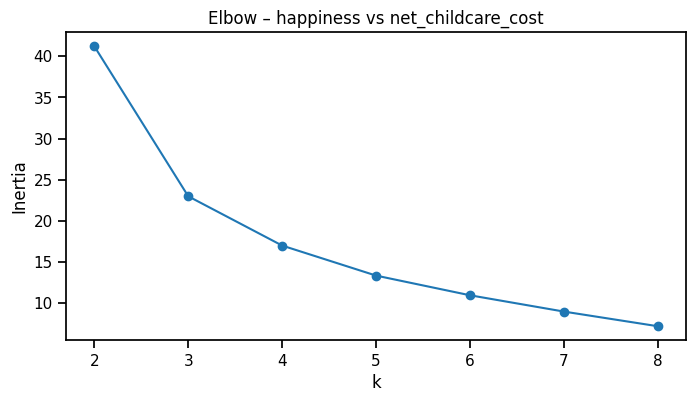

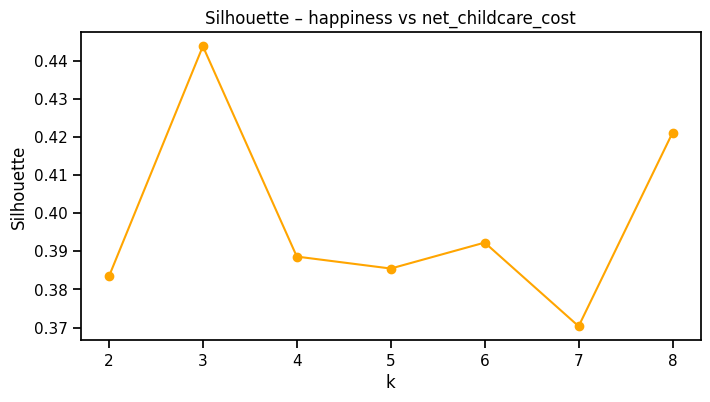


Pair: happiness, net_childcare_cost
Inertias: [(2, 41.21982388747659), (3, 22.98500018160742), (4, 16.99304093919486), (5, 13.344815033334111), (6, 10.953337002681268), (7, 8.971418612143871), (8, 7.190105004645017)]
Silhouettes: [(2, np.float64(0.38339657584814063)), (3, np.float64(0.4437716937707338)), (4, np.float64(0.38861414221542345)), (5, np.float64(0.3854758264128301)), (6, np.float64(0.39228404293473457)), (7, np.float64(0.3703431201082973)), (8, np.float64(0.4211051285958133))]


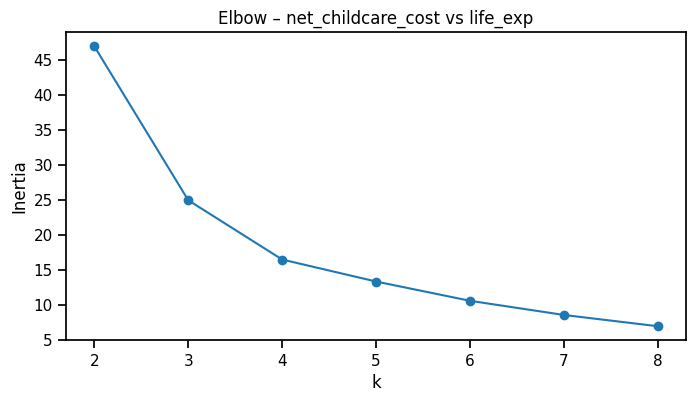

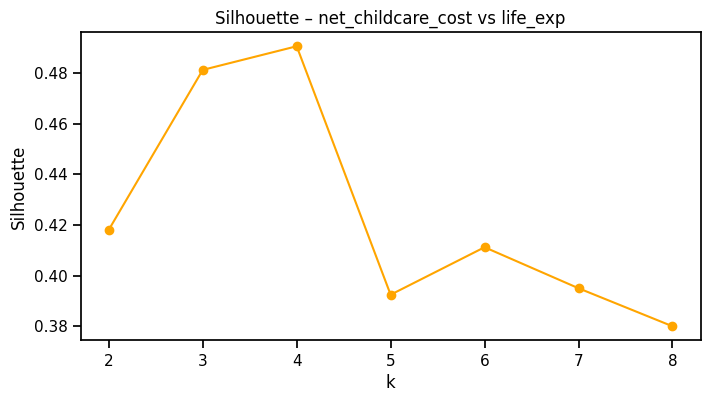


Pair: net_childcare_cost, life_exp
Inertias: [(2, 46.97353272699742), (3, 24.947463701743704), (4, 16.467444185916133), (5, 13.321818641248726), (6, 10.565056875931857), (7, 8.538747815892966), (8, 6.926017863562288)]
Silhouettes: [(2, np.float64(0.4181407730008232)), (3, np.float64(0.4812119878013476)), (4, np.float64(0.4905441915563937)), (5, np.float64(0.392495537146631)), (6, np.float64(0.4112348091949554)), (7, np.float64(0.39505160366799547)), (8, np.float64(0.3800530001483162))]


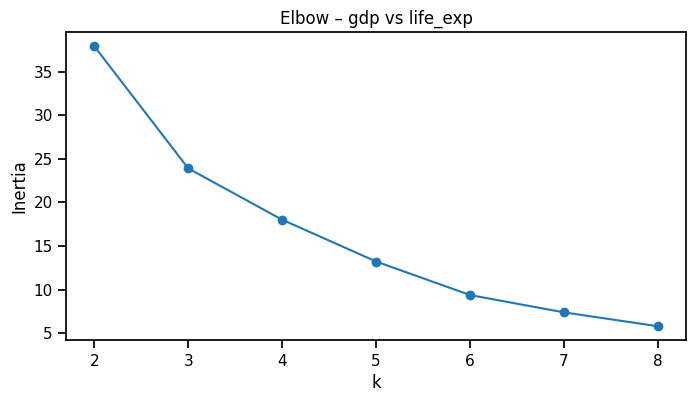

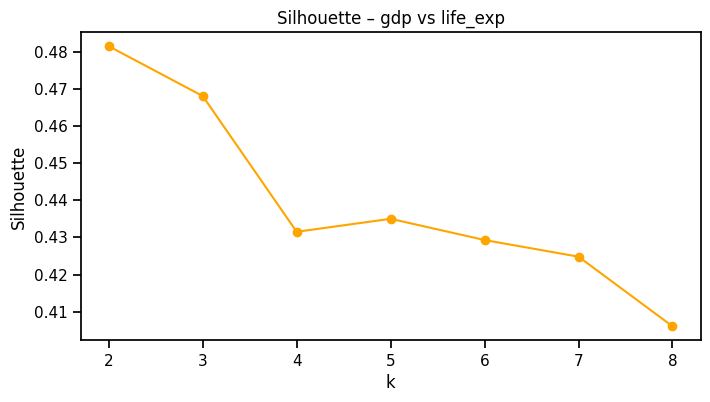


Pair: gdp, life_exp
Inertias: [(2, 37.90330210886474), (3, 23.89544309761951), (4, 18.005741619865127), (5, 13.214071988158693), (6, 9.367520601428888), (7, 7.382614378065411), (8, 5.789208812213411)]
Silhouettes: [(2, np.float64(0.4814659299642401)), (3, np.float64(0.46805135928407443)), (4, np.float64(0.43150232574988623)), (5, np.float64(0.435001747005598)), (6, np.float64(0.4292857587845777)), (7, np.float64(0.42480157496208043)), (8, np.float64(0.40606924086117996))]


In [ ]:

# ---------------------------------------------------
# 10. Elbow + Silhouette on Happiness vs Childcare Cost -- Focus Pairing and top 2 Silhouette Score
# ---------------------------------------------------


# This method was chosen to explore how these relationships behave in isolation.
# This determines if the top 2 and focus pairing support strong clustering, or a different K. Helping to further select a combination of variables to visualise.

focus_pairs = [
    ("happiness", "net_childcare_cost"),
]

# Add top 2 pairs from Section 17

top_2 = pair_scores_sorted[:2]
for (x, y, score, _) in top_2:
    focus_pairs.append((x, y))

print("\nEvaluating pairs:", focus_pairs)

# Run elbow + silhouette for each selected pair
for (x, y) in focus_pairs:
    X_pair = df_scaled[[x, y]].values

    inertias_pair = []
    silhouettes_pair = []

    for k in K:
        km = KMeans(n_clusters=k, n_init=50, random_state=42)
        labels = km.fit_predict(X_pair)
        inertias_pair.append(km.inertia_)
        silhouettes_pair.append(silhouette_score(X_pair, labels))

    # Plot elbow
    plt.figure(figsize=(8,4))
    plt.plot(K, inertias_pair, marker='o')
    plt.title(f"Elbow – {x} vs {y}")
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.show()

    # Plot silhouette
    plt.figure(figsize=(8,4))
    plt.plot(K, silhouettes_pair, marker='o', color="orange")
    plt.title(f"Silhouette – {x} vs {y}")
    plt.xlabel("k")
    plt.ylabel("Silhouette")
    plt.show()

    print(f"\nPair: {x}, {y}")
    print("Inertias:", list(zip(K, inertias_pair)))
    print("Silhouettes:", list(zip(K, silhouettes_pair)))

In [ ]:

## Focus Pair - Final K Means Model  (Childcare Cost + Happiness)

# This was chosen as it aligns with project goal - How can countries be grouped on childcare affordability and national happiness?
# Alternatives are explored later

#  =========================
# 11. Final data - Focus Pair
# =========================

X_final_focus = df_scaled[["net_childcare_cost", "happiness"]]

kmeans_final_focus = KMeans(n_clusters=3, n_init=50, random_state=42)  # K 3 chosen as best Silhouette and good elbow fow this combination step 10
df["cluster_final"] = kmeans_final_focus.fit_predict(X_final_focus) + 1


In [ ]:
# =========================
# 12. Cluster Profiling - Focus Pair  (Childcare Cost + Happiness)
# =========================

focus_features =  ["net_childcare_cost", "happiness"]

cluster_profile_final_focus = df.groupby("cluster_final")[focus_features].agg(["median", "mean"])

print("\nCluster Profile – Final Model (Childcare Cost + Happiness):")
print(cluster_profile_final_focus)

print("\nCluster Counts:")
print(df["cluster_final"].value_counts())



Cluster Profile – Final Model (Childcare Cost + Happiness):
              net_childcare_cost            happiness          
                          median       mean    median      mean
cluster_final                                                  
1                            5.0   5.333333    6.2362  6.232133
2                            6.0   5.416667    7.2717  7.240808
3                           17.0  17.750000    7.0027  7.039975

Cluster Counts:
cluster_final
1    18
2    12
3     8
Name: count, dtype: int64


In [ ]:
# =========================
# 13. Cluster Names - Focus Pair  (Childcare Cost + Happiness)
# =========================

cluster_names_focus = {
    1: "1 Low Childcare Cost & Low Happiness",
    2: "2 Medium Childcare Cost & High Happiness",
    3: "3 High Childcare Cost & High Happiness"
}

df["cluster_named"] = df["cluster_final"].map(cluster_names_focus)

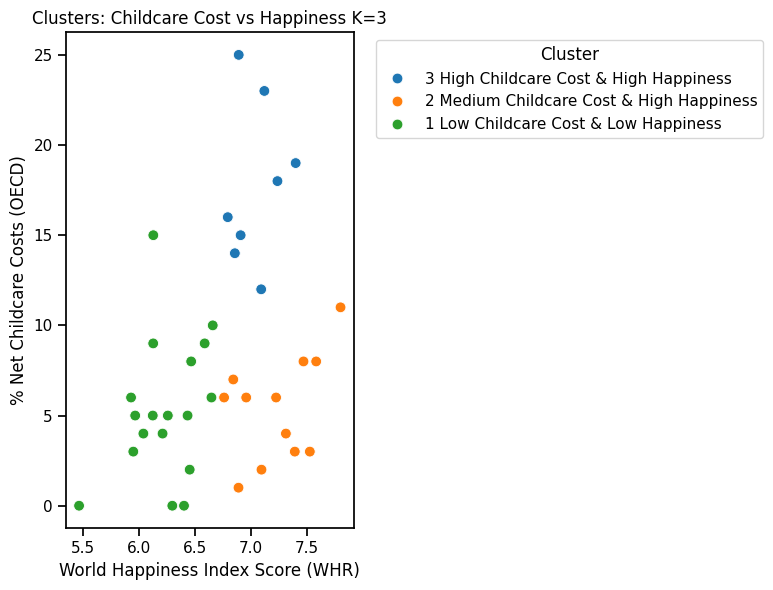

In [ ]:
# =========================
# 14. Scatter Plot - Focus Pair - (Childcare Cost + Happiness)
# =========================

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="happiness",
    y="net_childcare_cost",
    hue="cluster_named",
    palette="tab10",
    s = 60
)
plt.title("Clusters: Childcare Cost vs Happiness K=3")
plt.ylabel("% Net Childcare Costs (OECD)")
plt.xlabel("World Happiness Index Score (WHR)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 15. World Choropleth Map - Focus Pair - (Childcare Cost + Happiness)
# =========================

# Define a color palette for the clusters
plotly_cluster_palette = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Plot choropleth
fig = px.choropleth(
    df,
    locations="ISO",
    color="cluster_named",
    hover_name="Country Name",
    hover_data=["happiness", "net_childcare_cost"],
    color_discrete_sequence=plotly_cluster_palette,
    projection="natural earth",
    title="Childcare & Happiness Clusters K-3"
)

fig.update_layout(title_x=0.5)
fig.show()

# =========================
# 16. Summary Table for Results - Focus Pair - (Childcare Cost + Happiness)
# =========================

summary_table = df.groupby("cluster_final")[[
    "happiness",
    "net_childcare_cost"
]].agg(["median", "mean"])

print("\nSummary table (cluster-level):")
print(summary_table)



Summary table (cluster-level):
              happiness           net_childcare_cost           
                 median      mean             median       mean
cluster_final                                                  
1                6.2362  6.232133                5.0   5.333333
2                7.2717  7.240808                6.0   5.416667
3                7.0027  7.039975               17.0  17.750000


In [ ]:
# =========================
# Table of Countries and Cluster Names- Focus Pair - (Childcare Cost + Happiness)
# =========================

# Select relevant columns
country_cluster_table = df[["Country Name", "cluster_named"]]

# Sort by cluster for readability
country_cluster_table = country_cluster_table.sort_values(by="cluster_named")

print(country_cluster_table.to_string(index=False))

  Country Name                            cluster_named
         Italy     1 Low Childcare Cost & Low Happiness
         Malta     1 Low Childcare Cost & Low Happiness
        Latvia     1 Low Childcare Cost & Low Happiness
       Estonia     1 Low Childcare Cost & Low Happiness
        Poland     1 Low Childcare Cost & Low Happiness
         Japan     1 Low Childcare Cost & Low Happiness
        Greece     1 Low Childcare Cost & Low Happiness
      Slovakia     1 Low Childcare Cost & Low Happiness
       Romania     1 Low Childcare Cost & Low Happiness
       Croatia     1 Low Childcare Cost & Low Happiness
        France     1 Low Childcare Cost & Low Happiness
      Portugal     1 Low Childcare Cost & Low Happiness
        Cyprus     1 Low Childcare Cost & Low Happiness
         Spain     1 Low Childcare Cost & Low Happiness
      Bulgaria     1 Low Childcare Cost & Low Happiness
   South Korea     1 Low Childcare Cost & Low Happiness
       Hungary     1 Low Childcare Cost & Low Ha

# **Interpretation of Focus Model** **(Childcare Cost + Happiness)**

This focus model produced 3 distinct clusters, representing a different socio-economic pattern across the list of 38 countries with Childcare data avalible from the OECD data source.

**Cluster 1**

**Childcare cost - Very Low (median 5%)**

**Happiness - Low (median 6.2)**

These countries offer affordable childcare as a measure of % disposable income of average salary. But in these cases it does not result in happiness, this suggests that Childcare cost is not a key driver to the WHR measures of happiness in this cluster. Countries listed are mostly located in Central and Eastern Europe.These countries may have other factors driving lower happiness, such as low unemployment, freedom measures, or ecomonic instablity.
#
**Cluster 2**

**Childcare cost - Medium (median 6%)**

**Happiness - Very High (median 7.27)**

These countries offer higher happiness measures, but moderate childcare costs. They include the Nordic countries which are known to have higher quality public services and generous family polices such as extended parental leave. Higher income countries are also included here such as Germany, Iceland, Luxembourg and Canada. These places generally have higher living standards and culture of trust and safety.
#
**Cluster 3**

**Childcare cost - High (median 17%)**

**Happiness - High (median 7.0)**

These countries have high happiness, despite high childcare costs. This suggests that happiness is driven by other factors, such as higher quality of life or that there different cultural attitudes to childcare and families.  There could be a strain childcare support due to on pressure on other ecomonic support models such as pensions due to a rise in aging populations
The USA (25%) along with New Zealand (23%) in this cluster have the highest childcare costs as a % disposable income of average salary.

# **Key Insight**


*   Low childcare cost does not guarantee high happiness
*   Medium childcare costs with supportive social (Nordic style) policy has a more postive impact on happiness
*  High childcare costs can exsist alongside higher measures particularly in wealthier economies as other socio-economic factors could compensate for expensive childcare

Childcare affordability is not always an influencing factor on national happiness. It is instead part of wider socio-economic system.

Further study particually using a happines index of only families of those < 5 would further enhace the impact of clustering and could influence more specific policy change.


In [ ]:

#  =========================
# 17. Final data - Alternative Pair (Childcare Cost + Life Expectancy)
# =========================

# This model is included as the combination has the strongest silhoutte score from previous EDA.
# Additionally, it is an interesting combination for further exploration, as it covers a wide specturm of social challenges.

alt_focus = df_scaled[["net_childcare_cost", "life_exp"]]

kmeans_final_focus = KMeans(n_clusters=4, n_init=50, random_state=42)  # K 4 chosen as best Silhouette and good elbow fow this combination in step 10
df["alt_focus"] = kmeans_final_focus.fit_predict(X_final_focus) + 1


In [ ]:
# =========================
# 18. Cluster Profiling - Alternative Pair (Childcare Cost + Life Expectancy)
# =========================

focus_features = ["net_childcare_cost", "life_exp"]

alt_focus = df.groupby("alt_focus")[focus_features].agg(["median", "mean"])

print("\nCluster Profile – Alternative Pair (Childcare Cost + Life Expectancy):")
print(alt_focus)

print("\nCluster Counts:")
print(df["alt_focus"].value_counts())


Cluster Profile – Alternative Pair (Childcare Cost + Life Expectancy):
          net_childcare_cost              life_exp           
                      median       mean     median       mean
alt_focus                                                    
1                       17.0  17.750000  70.974514  70.524908
2                        4.0   3.090909  69.650169  69.795459
3                        8.0   8.333333  71.051849  70.576525
4                        5.0   5.200000  71.450031  71.632246

Cluster Counts:
alt_focus
2    11
4    10
3     9
1     8
Name: count, dtype: int64


In [ ]:
# =========================
# 19. Cluster Names - Alternative Pair (Childcare Cost + Life Expectancy)
# =========================

cluster_names_alt = {
    1: "1 High Childcare Cost & Medium Life Expectancy",
    2: "2 Low Childcare Cost & Lower Life Expectancy",
    3: "3 Medium Childcare Cost & Medium Life Expectancy",
    4: "4 Low Childcare Cost & Higher Life Expectancy",
}

df["alt_cluster_named"] = df["alt_focus"].map(cluster_names_alt)

In [ ]:
# =========================
# 20. World Choropleth Map -  Alternative Pair (Childcare Cost + Life Expectancy)
# =========================


cluster_order = [
    cluster_names_alt[1],
    cluster_names_alt[2],
    cluster_names_alt[3],
    cluster_names_alt[4]
]

plotly_cluster_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig = px.choropleth(
    df,
    locations="ISO",
    color="alt_cluster_named",
    hover_name="Country Name",
    hover_data=["life_exp", "net_childcare_cost"],
    color_discrete_sequence=plotly_cluster_palette,
    category_orders={"alt_cluster_named": cluster_order},
    projection="natural earth",
    title="Childcare Cost & Life Expectancy Clusters (K-4)"
)

fig.update_layout(title_x=0.5)
fig.show()

# =========================
# 16. Summary Table for Results -  Alternative Pair (Childcare Cost + Life Expectancy)
# =========================

summary_table = df.groupby("alt_focus")[[
        "life_exp",
    "net_childcare_cost"
]].agg(["median", "mean"])

print("\nSummary table (cluster-level):")
print(summary_table)



Summary table (cluster-level):
            life_exp            net_childcare_cost           
              median       mean             median       mean
alt_focus                                                    
1          70.974514  70.524908               17.0  17.750000
2          69.650169  69.795459                4.0   3.090909
3          71.051849  70.576525                8.0   8.333333
4          71.450031  71.632246                5.0   5.200000


In [ ]:
# =========================
# Table of Countries and Cluster Names-  Alternative Pair (Childcare Cost + Life Expectancy)
# =========================

# Select relevant columns
country_cluster_table = df[["Country Name", "alt_cluster_named"]]

# Sort by cluster for readability
country_cluster_table = country_cluster_table.sort_values(by="alt_cluster_named")

print(country_cluster_table.to_string(index=False))

  Country Name                                alt_cluster_named
   New Zealand   1 High Childcare Cost & Medium Life Expectancy
 United States   1 High Childcare Cost & Medium Life Expectancy
       Ireland   1 High Childcare Cost & Medium Life Expectancy
United Kingdom   1 High Childcare Cost & Medium Life Expectancy
     Australia   1 High Childcare Cost & Medium Life Expectancy
       Belgium   1 High Childcare Cost & Medium Life Expectancy
   Netherlands   1 High Childcare Cost & Medium Life Expectancy
   Switzerland   1 High Childcare Cost & Medium Life Expectancy
       Estonia     2 Low Childcare Cost & Lower Life Expectancy
        Poland     2 Low Childcare Cost & Lower Life Expectancy
        Greece     2 Low Childcare Cost & Lower Life Expectancy
       Croatia     2 Low Childcare Cost & Lower Life Expectancy
      Portugal     2 Low Childcare Cost & Lower Life Expectancy
        Latvia     2 Low Childcare Cost & Lower Life Expectancy
      Bulgaria     2 Low Childcare Cost 

# **Interpretation of Alternative Model** **(Childcare Cost + Life Expectancy)**

This focus model produced 4 distinct clusters, and was selected as this model had the highest silhoutte score from previous EDA. Each cluster shows how childcare costs influences life expectancy, highlighting differences in social support, demographic pressues and other wider socio economic factors


**Cluster 1**

**Childcare cost - High (median 17%)**

**Life Expectancy - Medium (median 70.97 years)**

These countries face significant childcare costs, but ahcieve a medium life expectancy. This could imply weaker health care systems, and economic inequaity. Countries include the USA, UK, Australia. Life expectancy although not low, does not align to expected values for stong economies.  

#
**Cluster 2**

**Childcare cost - Low (median 4%)**

**Life Expectancy - Lower (median 69.65)**

This cluster shows that affordable childcare does not lead to population health. Countries in this cluster are often eastern europe. Which have a lower GDP, and weaker healthcare.
#
**Cluster 3**

**Childcare cost - Medium (median 8%)**

**Life Expectancy - Medium (median 71.05)**

This cluster is relatively balanced, and represents a mix of Western Europe(Spain, France) and Eastern europe economies. Life expectancy and childcare costs are not the highest or the lowest.

**Cluster 4**

**Childcare cost - Low (median 5%)**

**Life Expectancy - Higher (median 71.45)**

This is the highest cluster in regards to both childcare costs and life expectancy. Higher quality of life in these areas is often linked to stonger economies and better social support systems. Countries include, Nordic regions, Germany and Canada.


# **Key Insight**

*   High childcare cost does not guarantee longer life expectancy (1)
*  Low childcare cost can be seen in both high and lower life expectancy clusters (2 & 4)
* Countries with stronger welfare systems tend to have higher life expectancy, regardless of chilcare cost.  

Childcare affordability is only a small part of larger socio-economic system, access to good healthcare and social support systems could be more likely to influence life expectancy.
